# **Atividade Prática**
<font size=3>

- **Tema:** Abordagens não-supervisionadas.
- **Prazo de entrega:** 11 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Com base no *dataset* `NewsGroups`, disponível no diretório $\text{dataset/}\,$, desenvolva as seguintes tarefas não-supervisionadas. Nas abordagens abaixo:
- Realize a vetorização seguido de SVD a fim de obter os vetores semântico;
- Utilize as ferramentas como Pipeline e RandomizedSearchCV para organizar e afinar hiperparâmetros do pré-processamento e modelo;
- Descreva em uma célula markdown qual o melhor modelo encontrado.

### **1. Questão:**
<font size=3>
    
- Treine o modelo [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) e o avalie com a métrica [`silhouette_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html). **Descreva** em uma **célula _markdown_** como funciona a métrica;

- Faça um plote bidimensional, utilizando [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), para a visualização dos *clusters*. Neste caso, o PCA é mais adequado do que utilizar o SVD já que os dados ficarão centralizados no gráfico — possibilitando melhor definição dos *clusters*.

  

#### Definições gerais e imports

In [1]:
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import seaborn           as sns
import nltk
import re

from IPython.display import display, HTML

from nltk.corpus   import  stopwords, wordnet
from nltk.tokenize import  word_tokenize
from nltk.stem     import  WordNetLemmatizer

from sklearn.base                     import  BaseEstimator
from sklearn.cluster                  import  KMeans
from sklearn.compose                  import  ColumnTransformer
from sklearn.decomposition            import  TruncatedSVD, PCA, LatentDirichletAllocation
from sklearn.ensemble                 import  RandomForestClassifier
from sklearn.feature_extraction.text  import  CountVectorizer, TfidfVectorizer
from sklearn.metrics                  import  accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, silhouette_score
from sklearn.model_selection          import  train_test_split, GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.neighbors                import  KNeighborsClassifier
from sklearn.pipeline                 import  Pipeline
from sklearn.preprocessing            import  StandardScaler, OneHotEncoder, LabelEncoder, normalize, Normalizer
from sklearn.svm                      import  SVC


In [2]:
RANDOM_STATE=42 # semente para garantir a reprodutibilidade dos resultados
TEST_SIZE=0.10 # proporção de dados para teste
N_ITER=50 # número de iterações para o RandomizedSearchCV
CV=5 # número de folds para o cross-validation

RANGE_MIN_DF = [5, 10, 15]
RANGE_MAX_DF = [0.20, 0.90]

##### Lendo os dados (do disco local)

In [3]:
df = pd.read_csv("./dataset/newsgroups.csv") # estou executando no meu notebook pessoal, não no google colab.
text_atribute = "reviews"

print(df.shape)

df.head()

(2752, 1)


,reviews
0,\n\n\n\n\n\nYour bad English? (See quote abov...
1,"I was a graduate student in the early 1980s, a..."
2,"\nIt doesn't make a whole lot of difference, a..."
3,\n\n\n\n
4,"Yesterday, I went to the Boeing shareholders m..."


##### Limpando nulos

In [4]:
print(f"ANTES: {df[text_atribute].isna().sum()}")
df = df.dropna(subset=[text_atribute])
df = df.reset_index(drop=True)
print(f"DEPOIS: {df[text_atribute].isna().sum()}")

df.count()

ANTES: 77
DEPOIS: 0


reviews    2675
dtype: int64

##### Definindo a função de pre-processamento do texto (limpeza)

In [5]:
nltk.download('stopwords')

nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # mantém apenas letras e espaços
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = [
        lemmatizer.lemmatize(token)
        for token in text.split()
        if token not in stop_words and len(token) > 1
    ]

    text = " ".join(tokens)

    text = re.sub(r"\s+", " ", text).strip()

    return text

for i in range(0,4):
    text_antes = df.iloc[i][text_atribute]
    texto_depois = preprocess_text(text_antes)
    print(f"TEXTO {i} ANTES.:@@@{text_antes}@@@FINAL")
    print(f"TEXTO {i} DEPOIS:@@@{texto_depois}@@@FINAL")
    print("--------------------------------")



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


TEXTO 0 ANTES.:@@@





Your bad English?  (See quote above.)



You'd lose that wager, if the supporting argument were part of it.


Did you know that Hitler himself was a devout Christian?  And heterosexual?

--Drywid@@@FINAL
TEXTO 0 DEPOIS:@@@bad english see quote lose wager supporting argument part know hitler devout christian heterosexual drywid@@@FINAL
--------------------------------
TEXTO 1 ANTES.:@@@I was a graduate student in the early 1980s, and we had a conference on 
Reaganomics where Jerry Jordan, then a member of the Council of Economic 
Advisors, was a speaker.  I had the pleasure of driving him back to the 
airport afterwards, and since taxes were the main topic of discussion I 
thought I would ask him about the VAT.  I have favored it for these reasons 
you mention, that the income base is too hazy to define, that it taxes 
savings and investment, that it is likely to be more visible.  He agreed, 
and reported that the CEA at that time was in favor of VAT.  So why not

##### Investigando o tamanho e a qualidade do corpus

In [6]:
vectorizer_grid = {
    "min_df": RANGE_MIN_DF,
    "max_df": RANGE_MAX_DF,
}
corpus_inspection = []

for params in ParameterGrid(vectorizer_grid):
    vec = TfidfVectorizer(
        preprocessor=preprocess_text,
        min_df=params["min_df"],
        max_df=params["max_df"]
    )

    X_vec = vec.fit_transform(df[text_atribute])
    terms = vec.get_feature_names_out()

    corpus_inspection.append({
        "min_df": params["min_df"],
        "max_df": params["max_df"],
        "matrix_shape": X_vec.shape,
        "first_terms": terms[:20].tolist(),
        "last_terms": terms[-20:].tolist(),
        "underscore_terms": [t for t in terms if "_" in t][:20],
        "numeric_terms": [t for t in terms if any(ch.isdigit() for ch in t)][:20],
        "one_char_terms": [t for t in terms if len(t) == 1][:20],
        "vectorizer": vec
    })

inspection_df = pd.DataFrame(corpus_inspection)

display(inspection_df[[
    "min_df",
    "max_df",
    "matrix_shape",
    "underscore_terms",
    "numeric_terms",
    "one_char_terms"    
]])

,min_df,max_df,matrix_shape,underscore_terms,numeric_terms,one_char_terms
0,5,0.2,"(2675, 5717)",[],[],[]
1,10,0.2,"(2675, 3336)",[],[],[]
2,15,0.2,"(2675, 2401)",[],[],[]
3,5,0.9,"(2675, 5722)",[],[],[]
4,10,0.9,"(2675, 3341)",[],[],[]
5,15,0.9,"(2675, 2406)",[],[],[]


##### Exibindo alguns tokens de uma combinação particular

In [7]:
selected = inspection_df[
    (inspection_df["min_df"] == 10) &
    (inspection_df["max_df"] == 0.90)
].iloc[0]

print("FIRST TERMS")
print(selected["first_terms"])

print("\nLAST TERMS")
print(selected["last_terms"])

print("\nUNDERSCORE TERMS")
print(selected["underscore_terms"])

print("\nNUMERIC TERMS")
print(selected["numeric_terms"])

print("\nONE CHAR TERMS")
print(selected["one_char_terms"])

FIRST TERMS
['ab', 'ability', 'able', 'abortion', 'absence', 'absolute', 'absolutely', 'abuse', 'abused', 'ac', 'academic', 'acceleration', 'accept', 'acceptable', 'accepted', 'access', 'accessible', 'accident', 'accomplish', 'accomplished']

LAST TERMS
['writer', 'writes', 'writing', 'written', 'wrong', 'wrote', 'wwii', 'ya', 'yeah', 'year', 'yellow', 'yes', 'yesterday', 'yet', 'york', 'young', 'youth', 'yup', 'zero', 'zone']

UNDERSCORE TERMS
[]

NUMERIC TERMS
[]

ONE CHAR TERMS
[]


##### Exibindo alguns tokens das configuracoes com min_df = 10

In [8]:
for _, row in inspection_df.iterrows():

    if row['min_df'] == 10:
        vec = row["vectorizer"]
        terms = vec.get_feature_names_out()

        print("=" * 80)
        print(f"min_df={row['min_df']} | max_df={row['max_df']}")
        print(f"shape={row['matrix_shape']}")
        print(terms[:100])
        print(terms[-100:])

min_df=10 | max_df=0.2
shape=(2675, 3336)
['ab' 'ability' 'able' 'abortion' 'absence' 'absolute' 'absolutely'
 'abuse' 'abused' 'ac' 'academic' 'acceleration' 'accept' 'acceptable'
 'accepted' 'access' 'accessible' 'accident' 'accomplish' 'accomplished'
 'accord' 'according' 'account' 'accuracy' 'accurate' 'achieve' 'achieved'
 'acid' 'across' 'act' 'acting' 'action' 'active' 'actively' 'activist'
 'activity' 'actual' 'actually' 'ad' 'adam' 'add' 'added' 'adding'
 'addition' 'additional' 'address' 'adequate' 'adjust' 'adjustment'
 'administration' 'administrator' 'admit' 'adult' 'advance' 'advanced'
 'advantage' 'advertising' 'advice' 'advisory' 'advocate' 'advocating'
 'aeronautics' 'aerospace' 'af' 'affair' 'affect' 'affected' 'afford'
 'afraid' 'africa' 'african' 'afternoon' 'age' 'agency' 'agenda' 'agent'
 'ago' 'agree' 'agreed' 'agreement' 'ah' 'ahead' 'aiaa' 'aid' 'aimed'
 'air' 'airbag' 'aircraft' 'airplane' 'airport' 'al' 'alabama' 'alarm'
 'alaska' 'alcohol' 'alignment' 'alive

##### Definindo pipeline sem normalizar SVD

In [9]:
# Definindo transformação de textos:
text_pipe_tfidf = Pipeline(steps=[
                                ("vec", TfidfVectorizer(preprocessor=preprocess_text)),
                                ("svd", TruncatedSVD(random_state=RANDOM_STATE)),
                                # Importante a normalização para melhorar classificação do KMeans, que utiliza distancia euclidiana.
                                # Normalizar os dados faz com que a distancia euclidiana se aproxime da distancia por coseno, melhorando a classificação.
                                # Isso por que TF-IDF gera informação semantica associada a direção, não a magnitude do vetor.
                                # Vamos testar isso empiricamente.
                                # ("norm", Normalizer())
                          ])

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor_tfidf = ColumnTransformer(transformers=[("text", text_pipe_tfidf, text_atribute)],
                                       remainder='drop' # colunas que não foram identificadas serão removidas
                                      )

pipe_tfidf = Pipeline(steps=[
                        ('preprocessor', preprocessor_tfidf),
                        ('classifier', KMeans(random_state=RANDOM_STATE, verbose=0, init="k-means++", n_init=20, max_iter=300))
                     ])

pipe_tfidf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

##### Definindo pipeline com normalização após o SVD

In [10]:
# Definindo transformação de textos:
text_pipe_tfidf_norm = Pipeline(steps=[
                                    ("vec", TfidfVectorizer(preprocessor=preprocess_text)),
                                    ("svd", TruncatedSVD(random_state=RANDOM_STATE)),
                                    # Importante a normalização para melhorar classificação do KMeans, que utiliza distancia euclidiana.
                                    # Normalizar os dados faz com que a distancia euclidiana se aproxime da distancia por coseno, melhorando a classificação.
                                    # Isso por que TF-IDF gera informação semantica associada a direção, não a magnitude do vetor.
                                    # Vamos testar isso empiricamente.
                                    ("norm", Normalizer())
                               ])

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor_tfidf_norm = ColumnTransformer(transformers=[("text", text_pipe_tfidf_norm, text_atribute)],
                                            remainder='drop' # colunas que não foram identificadas serão removidas
                                           )

pipe_tfidf_norm = Pipeline(steps=[
                            ('preprocessor', preprocessor_tfidf_norm),
                            ('classifier', KMeans(random_state=RANDOM_STATE, verbose=0, init="k-means++", n_init=20, max_iter=300))
                          ])

pipe_tfidf_norm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

##### Definindo metricas de scorer para silhouette com métrica de distancia euclidiana e por cosseno

In [11]:
def kmeans_silhouette_scorer(estimator, X, y=None):
    X_transformed = estimator.named_steps["preprocessor"].transform(X)
    labels = estimator.named_steps["classifier"].predict(X_transformed)

    if len(set(labels)) < 2:
        return -1

    return silhouette_score(X_transformed, labels)

def kmeans_silhouette_scorer_cosine(estimator, X, y=None):
    X_transformed = estimator.named_steps["preprocessor"].transform(X)
    labels = estimator.named_steps["classifier"].predict(X_transformed)

    if len(set(labels)) < 2:
        return -1

    return silhouette_score(X_transformed, labels, metric="cosine")


##### Definindo o Grid para o Search (já previamente curado)

In [12]:

param_grid_tfidf = {
    "preprocessor__text__vec__min_df": RANGE_MIN_DF,
    "preprocessor__text__vec__max_df": RANGE_MAX_DF,
    "preprocessor__text__svd__n_components": [2, 5, 25, 50],
    "classifier__n_clusters": [2, 3, 5, 8],
}
total = np.prod([len(v) for v in param_grid_tfidf.values()])
print(f"Tamanho do espaco de busca: {total}")

Tamanho do espaco de busca: 96


##### Definindo função de search generica para GridSearch com os dois pipelines

In [13]:
def run_search(
    pipe,
    param_grid,
    scoring,
    df,
    title,
    ax=None,
    top_n=3,
    cv=5,
    random_state=42,
    n_jobs=-1
):
    search_cv = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        verbose=False,
        n_jobs=n_jobs
    )

    search_cv.fit(df)

    results = pd.DataFrame(search_cv.cv_results_)
    display_results_summary(results, search_cv, top_n, title=title)
    
    best_pipe = search_cv.best_estimator_

    # Labels do KMeans no espaço usado pelo modelo
    labels = best_pipe.named_steps["classifier"].labels_

    # Espaço latente ANTES do Normalizer
    X_latent = transform_to_latent_space(best_pipe, df)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    plot_clusters_latent_space(
        X_latent=X_latent,
        labels=labels,
        score=search_cv.best_score_,
        title=title,
        ax=ax,
        random_state=random_state
    )

    return search_cv, results


def transform_to_latent_space(best_pipe, df):
    text_pipeline = best_pipe.named_steps["preprocessor"].named_transformers_["text"]

    vectorizer = text_pipeline.named_steps["vec"]
    svd = text_pipeline.named_steps["svd"]

    text_column = best_pipe.named_steps["preprocessor"].transformers_[0][2]

    X_tfidf = vectorizer.transform(df[text_column])
    X_latent = svd.transform(X_tfidf)

    return X_latent


def display_results_summary(results, search_cv, top_n=3, title="Resultado do GridSearch"):
    top = (
        results.sort_values("mean_test_score", ascending=False)
        .head(top_n)
        .copy()
    )

    bottom = (
        results.sort_values("mean_test_score", ascending=True)
        .head(top_n)
        .copy()
    )

    def format_table(df_result):
        table = df_result[["mean_test_score", "std_test_score", "params"]].copy()
        table["mean_test_score"] = table["mean_test_score"].map(lambda x: f"{x:.5f}")
        table["std_test_score"] = table["std_test_score"].map(lambda x: f"{x:.5f}")
        table["params"] = table["params"].astype(str)
        return table

    display(HTML(f"<h3>{title}</h3>"))
    display(HTML(f"<b>Melhor score:</b> {search_cv.best_score_:.5f}<br>"))
    display(HTML(f"<b>Melhores parâmetros:</b><pre>{search_cv.best_params_}</pre>"))

    display(HTML(f"<h4>Top {top_n}</h4>"))
    display(
        format_table(top).style
            .set_table_styles([
                {
                    "selector": "th",
                    "props": [("text-align", "left")]
                }
            ])
            .set_properties(
                subset=["params"],
                **{
                    "max-width": "900px",
                    "white-space": "pre-wrap",
                    "font-family": "monospace"
                }
            )
    )


    display(HTML(f"<h4>Bottom {top_n}</h4>"))
    display(
        format_table(bottom).style
            .set_table_styles([
                {
                    "selector": "th",
                    "props": [("text-align", "left")]
                }
            ])
            .set_properties(
                subset=["params"],
                **{
                    "max-width": "900px",
                    "white-space": "pre-wrap",
                    "font-family": "monospace"
                }
            )
    )

def plot_clusters_latent_space(X_latent, labels, score, title, ax, random_state=42):
    if X_latent.shape[1] == 2:
        # SVD já gerou 2 dimensoes, usa SVD diretamente
        X_plot = X_latent
        x_label = "SVD 1"
        y_label = "SVD 2"
    else:
        # SVD gerou mais de 2 dimensoes, precisa projetar em 2D com PCA
        pca = PCA(n_components=2, random_state=random_state)
        X_plot = pca.fit_transform(X_latent)
        x_label = "PCA 1 sobre espaço latente"
        y_label = "PCA 2 sobre espaço latente"

    scatter = ax.scatter(
        X_plot[:, 0],
        X_plot[:, 1],
        c=labels,
        alpha=0.7
    )

    ax.set_title(f"{title}\nSilhouette: {score:.4f}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    legend = ax.legend(
        *scatter.legend_elements(),
        title="Clusters",
        loc="best"
    )
    ax.add_artist(legend)

##### Cria grafico base para plot das variações

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.close(fig)

##### Executa search para pipeline com tfidf sem normalização e métrica de distancia euclidiana para sillouette

In [15]:
search_no_norm_euc, results_no_norm_euc = run_search(
    pipe=pipe_tfidf,
    param_grid=param_grid_tfidf,
    scoring=kmeans_silhouette_scorer,
    df=df,
    title="Sem Normalizer + Silhouette Euclidean",
    ax=axes[0, 0],
    cv=CV,
    random_state=RANDOM_STATE
)

,mean_test_score,std_test_score,params
2,0.51444,0.02000,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"
1,0.50457,0.02129,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 10}"
5,0.49912,0.01852,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"


,mean_test_score,std_test_score,params
95,0.07618,0.01063,"{'classifier__n_clusters': 8, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"
93,0.08677,0.01250,"{'classifier__n_clusters': 8, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 5}"
71,0.08760,0.00709,"{'classifier__n_clusters': 5, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"


##### Executa search para pipeline com tfidf sem normalização e métrica de distancia por cosseno para sillouette

In [16]:
search_no_norm_cos, results_no_norm_cos = run_search(
    pipe=pipe_tfidf,
    param_grid=param_grid_tfidf,
    scoring=kmeans_silhouette_scorer_cosine,
    df=df,
    title="Sem Normalizer + Silhouette Cosine",
    ax=axes[0, 1],
    cv=CV,
    random_state=RANDOM_STATE
)

,mean_test_score,std_test_score,params
2,0.65125,0.02414,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"
5,0.65017,0.02066,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"
4,0.64804,0.02049,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 10}"


,mean_test_score,std_test_score,params
75,-0.28845,0.08532,"{'classifier__n_clusters': 8, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 5}"
76,-0.25785,0.05199,"{'classifier__n_clusters': 8, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 10}"
72,-0.24765,0.04452,"{'classifier__n_clusters': 8, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 5}"


##### Executa search para pipeline com tfidf + normalização e métrica de distancia euclidiana para sillouette

In [17]:
search_norm_euc, results_norm_euc = run_search(
    pipe=pipe_tfidf_norm,
    param_grid=param_grid_tfidf,
    scoring=kmeans_silhouette_scorer,
    df=df,
    title="Com Normalizer + Silhouette Euclidean",
    ax=axes[1, 0],
    cv=CV,
    random_state=RANDOM_STATE
)

,mean_test_score,std_test_score,params
2,0.64919,0.02032,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"
1,0.64597,0.02415,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 10}"
5,0.64487,0.01671,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"


,mean_test_score,std_test_score,params
23,0.05059,0.00407,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"
22,0.05223,0.00341,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 10}"
20,0.05230,0.00330,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"


##### Executa search para pipeline com tfidf + normalização e métrica de distancia por cosseno para sillouette

In [18]:
search_norm_cos, results_norm_cos = run_search(
    pipe=pipe_tfidf_norm,
    param_grid=param_grid_tfidf,
    scoring=kmeans_silhouette_scorer_cosine,
    df=df,
    title="Com Normalizer + Silhouette Cosine",
    ax=axes[1, 1],
    cv=CV,
    random_state=RANDOM_STATE
)

,mean_test_score,std_test_score,params
2,0.77922,0.02056,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"
0,0.77691,0.02660,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 5}"
1,0.77658,0.02550,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 2, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 10}"


,mean_test_score,std_test_score,params
23,0.08285,0.00645,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 15}"
20,0.08550,0.00499,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.2, 'preprocessor__text__vec__min_df': 15}"
22,0.08598,0.00534,"{'classifier__n_clusters': 2, 'preprocessor__text__svd__n_components': 50, 'preprocessor__text__vec__max_df': 0.9, 'preprocessor__text__vec__min_df': 10}"


##### Exibe graficos construidos em cada um dos pipelines

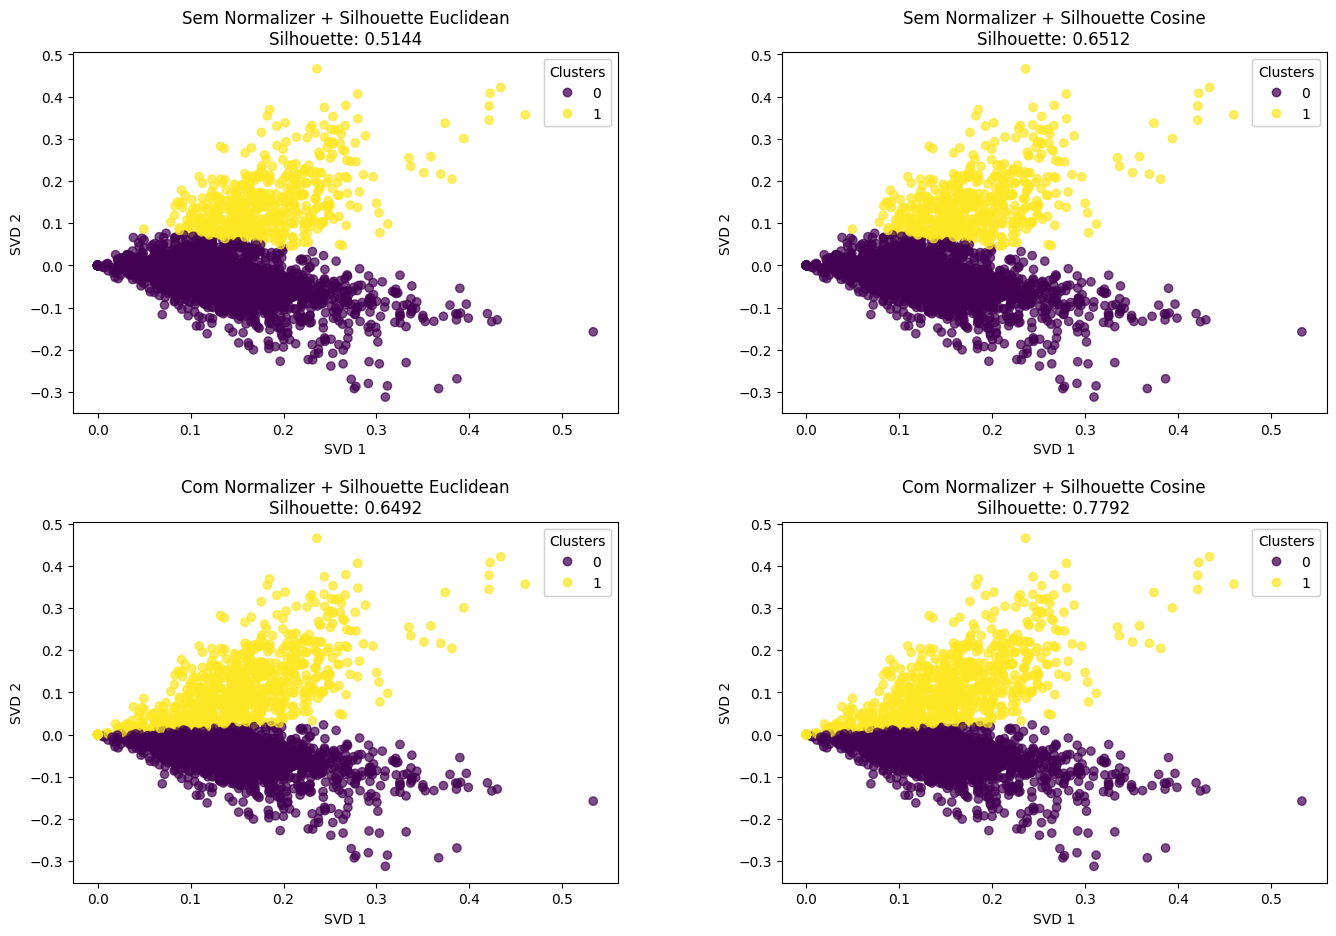

In [19]:
fig.tight_layout(pad=3.0)
fig.subplots_adjust(hspace=0.3, wspace=0.3)
fig

##### Armazena melhores resultados no dataframe

In [20]:
df["cluster_norm_cosine"] = search_norm_cos.best_estimator_.predict(df)
df["cluster_norm_euclid"] = search_norm_euc.best_estimator_.predict(df)
df["cluster_no_norm_cosine"] = search_no_norm_cos.best_estimator_.predict(df)
df["cluster_no_norm_euclid"] = search_no_norm_euc.best_estimator_.predict(df)

### **2. Questão:**
<font size=3>

Utilize o modelo de Alocação Latente de Dirichlet a fim de realizar a análise de tópicos. Para isso:
- Imprima na tela a quantidade de tópicos que melhor ajustou aos dados;
- Plote as 10 palavras mais associadas a cada tópico;
- Plote 10 documentos com a distribuição de tópicos;
- Escreva em uma célula markdown sua interpretação desses resultados. 

##### Definindo pipeline com Bag of Words sem normalização

In [21]:
# Definindo transformação de textos:
text_pipe_bow = Pipeline(steps=[
                              ("vec", CountVectorizer(preprocessor=preprocess_text)),
                              # ("svd", TruncatedSVD(random_state=RANDOM_STATE)),
                              # Importante a normalização para melhorar classificação do KMeans, que utiliza distancia euclidiana.
                              # Normalizar os dados faz com que a distancia euclidiana se aproxime da distancia por coseno, melhorando a classificação.
                              # Isso por que TF-IDF gera informação semantica associada a direção, não a magnitude do vetor.
                              # Vamos testar isso empiricamente.
                              # ("norm", Normalizer())
                        ])

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor_bow = ColumnTransformer(transformers=[("text", text_pipe_bow, text_atribute)],
                                     remainder='drop' # colunas que não foram identificadas serão removidas
                                    )

pipe_bow = Pipeline(steps=[
                        ('preprocessor', preprocessor_bow),
                        ('classifier', LatentDirichletAllocation(random_state=RANDOM_STATE, n_jobs=-1, verbose=0))
                   ])

pipe_bow

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

##### Definindo pipeline com Bag of Words + normalização

In [22]:
# Definindo transformação de textos:
text_pipe_bow_norm = Pipeline(steps=[
                                 ("vec", CountVectorizer(preprocessor=preprocess_text)),
                                 # ("svd", TruncatedSVD(random_state=RANDOM_STATE)),
                                 # Importante a normalização para melhorar classificação do KMeans, que utiliza distancia euclidiana.
                                 # Normalizar os dados faz com que a distancia euclidiana se aproxime da distancia por coseno, melhorando a classificação.
                                 # Isso por que TF-IDF gera informação semantica associada a direção, não a magnitude do vetor.
                                 # Vamos testar isso empiricamente.
                                 ("norm", Normalizer())
                             ])

# definindo o objeto ColumnTransformer para aplicar as transformações em X:
preprocessor_bow_norm = ColumnTransformer(transformers=[("text", text_pipe_bow_norm, text_atribute)],
                                          remainder='drop' # colunas que não foram identificadas serão removidas
                                         )

pipe_bow_norm = Pipeline(steps=[
                          ('preprocessor', preprocessor_bow_norm),
                          ('classifier', LatentDirichletAllocation(random_state=RANDOM_STATE, n_jobs=-1, verbose=0))
                        ])

pipe_bow_norm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

##### Definindo grid para random search

In [23]:

param_grid_bow = {
    "preprocessor__text__vec__min_df": RANGE_MIN_DF,
    "preprocessor__text__vec__max_df": RANGE_MAX_DF,
    "classifier__n_components": [2, 3, 5, 8],
    "classifier__doc_topic_prior": [None, 0.1, 0.5, 1.0],
    "classifier__topic_word_prior": [None, 0.01, 0.1, 0.5],
}
total = np.prod([len(v) for v in param_grid_bow.values()])
print(f"Tamanho do espaco de busca: {total}")

Tamanho do espaco de busca: 384


##### Definindo função de busca genérica para LDA

In [24]:
def run_lda_search(
    pipe,
    param_grid,
    scoring,
    df,
    n_iter=N_ITER,
    random_state=RANDOM_STATE,
    title="Resultado LDA",
    top_n=3,
    cv=5,
    n_jobs=-1
):
    # search_cv = GridSearchCV(
    #     estimator=pipe,
    #     param_grid=param_grid,
    #     cv=cv,
    #     scoring=scoring,
    #     verbose=0,
    #     n_jobs=n_jobs
    # )
    search_cv = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        verbose=0,
        random_state=random_state,
        n_jobs=n_jobs
    )

    search_cv.fit(df)

    results = pd.DataFrame(search_cv.cv_results_)

    display_results_summary(
        results=results,
        search_cv=search_cv,
        top_n=top_n,
        title=title
    )

    best_pipe = search_cv.best_estimator_

    X_bow = best_pipe.named_steps["preprocessor"].transform(df)
    lda = best_pipe.named_steps["classifier"]

    doc_topic = lda.transform(X_bow)

    return {
        "search_cv": search_cv,
        "results": results,
        "best_pipe": best_pipe,
        "X_bow": X_bow,
        "lda": lda,
        "doc_topic": doc_topic,
        "best_score": search_cv.best_score_,
        "best_params": search_cv.best_params_,
    }

##### Definindo explicitamente o score do LDA

In [25]:
def lda_log_likelihood_scorer(estimator, X):
    return estimator.score(X)

##### Executando RandomSearch para BoW sem normalização

In [26]:
lda_result_bow = run_lda_search(
    pipe=pipe_bow,
    param_grid=param_grid_bow,
    scoring=lda_log_likelihood_scorer,
    df=df,
    title="LDA + BoW",
    n_iter=N_ITER,
    top_n=3,
    cv=CV,
    n_jobs=-1
)

/Users/gilcesarf/git/repositories/imd/imd1107-202601/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gilcesarf/git/repositories/imd/imd1107-202601/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gilcesarf/git/repositories/imd/imd1107-202601/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

,mean_test_score,std_test_score,params
42,-261021.51652,28106.19939,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.5, 'classifier__n_components': 2, 'classifier__doc_topic_prior': 0.1}"
3,-261165.31070,26771.93790,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.5, 'classifier__n_components': 3, 'classifier__doc_topic_prior': 1.0}"
14,-264144.56230,28134.30614,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.1, 'classifier__n_components': 2, 'classifier__doc_topic_prior': 0.1}"


,mean_test_score,std_test_score,params
33,-400955.41007,34813.60311,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 8, 'classifier__doc_topic_prior': None}"
49,-395860.89188,37499.01347,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.9, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 5, 'classifier__doc_topic_prior': None}"
6,-384962.04884,38127.52865,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.9, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 3, 'classifier__doc_topic_prior': None}"


In [27]:
def select_significant_documents_per_topic(
    θ,
    X,
    n_docs=10
):
    n_topics = θ.shape[1]

    valid_docs = np.asarray(X.sum(axis=1)).ravel() > 0
    valid_idx = np.where(valid_docs)[0]

    if n_topics == 2:
        n_top_per_topic = 4
        n_mixed = n_docs - (2 * n_top_per_topic)

        top_topic_0 = valid_idx[np.argsort(θ[valid_idx, 0])[-n_top_per_topic:]][::-1]

        top_topic_1 = valid_idx[np.argsort(θ[valid_idx, 1])[-n_top_per_topic:]][::-1]

        mixed_docs = valid_idx[
            np.argsort(
                np.abs(θ[valid_idx, 0] - θ[valid_idx, 1])
            )[:n_mixed]
        ]

        selected_docs = np.concatenate([
            top_topic_0,
            top_topic_1,
            mixed_docs
        ])
    else:
        docs_per_topic = max(1, n_docs // n_topics)

        selected_docs = []

        for topic_idx in range(n_topics):
            top_docs = valid_idx[
                np.argsort(
                    θ[valid_idx, topic_idx]
                )[-docs_per_topic:]
            ][::-1]

            selected_docs.extend(top_docs)

        selected_docs = np.array(selected_docs)

    selected_docs = np.array(
        list(dict.fromkeys(selected_docs))
    )

    selected_docs = selected_docs[:n_docs]

    return selected_docs

In [28]:
def plot_words_per_topic(
    model,
    vocab,
    n_top_words=10,
    title="Palavras Mais Relevantes por Tópico"
):
    n_topics = model.n_components

    fig, axes = plt.subplots(
        1,
        n_topics,
        figsize=(7 * n_topics, 6),
        sharex=False
    )

    fig.suptitle(title, fontsize=18)

    if n_topics == 1:
        axes = [axes]

    axes = np.array(axes).flatten()

    β = model.components_

    for topic_idx, topic in enumerate(β):
        top_tokens_index = topic.argsort()[:-n_top_words - 1:-1]

        top_tokens = [vocab[i] for i in top_tokens_index]
        weights = topic[top_tokens_index]

        top_tokens = top_tokens[::-1]
        weights = weights[::-1]

        ax = axes[topic_idx]

        ax.barh(
            top_tokens,
            weights,
            alpha=0.8
        )

        ax.set_title(f"Tópico #{topic_idx + 1}", fontsize=14)
        ax.set_xlabel("Importância (Peso)", fontsize=12)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [29]:
def plot_significant_documents_per_topic(
    selected_docs,
    θ,
    title="Distribuição de Tópicos em Documentos de Amostra"
):
    θ_sample = θ[selected_docs]

    n_topics = θ.shape[1]

    doc_labels = [f"Doc {i}" for i in selected_docs]

    plt.figure(figsize=(12, 7))
    plt.title(title, fontsize=16)

    bottom = np.zeros(len(selected_docs))

    for topic_idx in range(n_topics):
        proportions = θ_sample[:, topic_idx]

        plt.bar(
            doc_labels,
            proportions,
            bottom=bottom,
            label=f"Tópico #{topic_idx + 1}",
            alpha=0.7
        )

        bottom += proportions

    plt.ylim(0, 1)
    plt.xlabel("Documento")
    plt.ylabel("Proporção do Tópico")
    plt.xticks(rotation=45)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()
    plt.show()

In [30]:
def print_significant_documents_per_topic(
    selected_docs,
    θ,
    df,
    text_column,
    max_chars=500
):
    for rank, doc_idx in enumerate(selected_docs, start=1):
        print(f"Documento #{rank} (idx={doc_idx})")
        print(
            f"Distribuição tópicos: "
            f"{[f'{x:.2%}' for x in θ[doc_idx]]}"
        )

        text = df.iloc[doc_idx][text_column]

        print(f"\nTrecho dos primeiros {max_chars} caracteres:")
        print(text[:max_chars])

        print("=" * 100)

In [31]:
best_pipe = lda_result_bow["best_pipe"]

model = best_pipe.named_steps["classifier"]

vectorizer = (
    best_pipe
    .named_steps["preprocessor"]
    .named_transformers_["text"]
    .named_steps["vec"]
)

vocab = vectorizer.get_feature_names_out()

X = best_pipe.named_steps["preprocessor"].transform(df)

θ_bow = model.transform(X)

selected_docs = select_significant_documents_per_topic(
    θ=θ_bow,
    X=X,
    n_docs=12
)
df["lda_θ_bow_topic_0"] = θ_bow[:, 0]
df["lda_θ_bow_topic_1"] = θ_bow[:, 1]

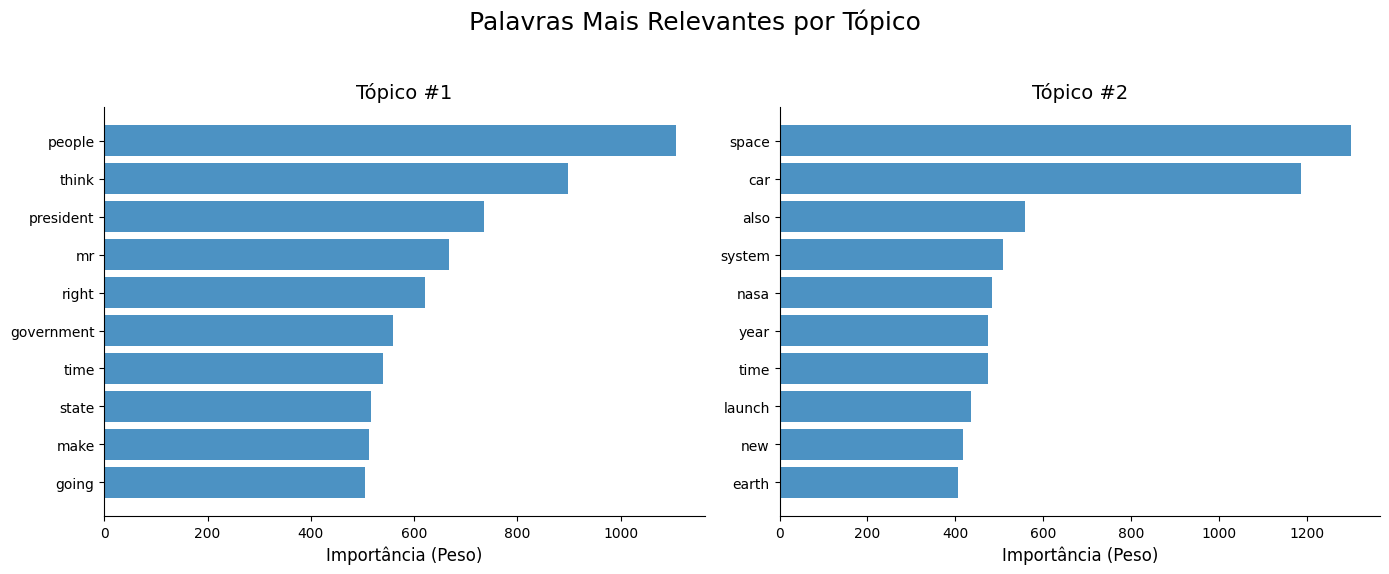

In [32]:

plot_words_per_topic(
    model=model,
    vocab=vocab,
    n_top_words=10
)


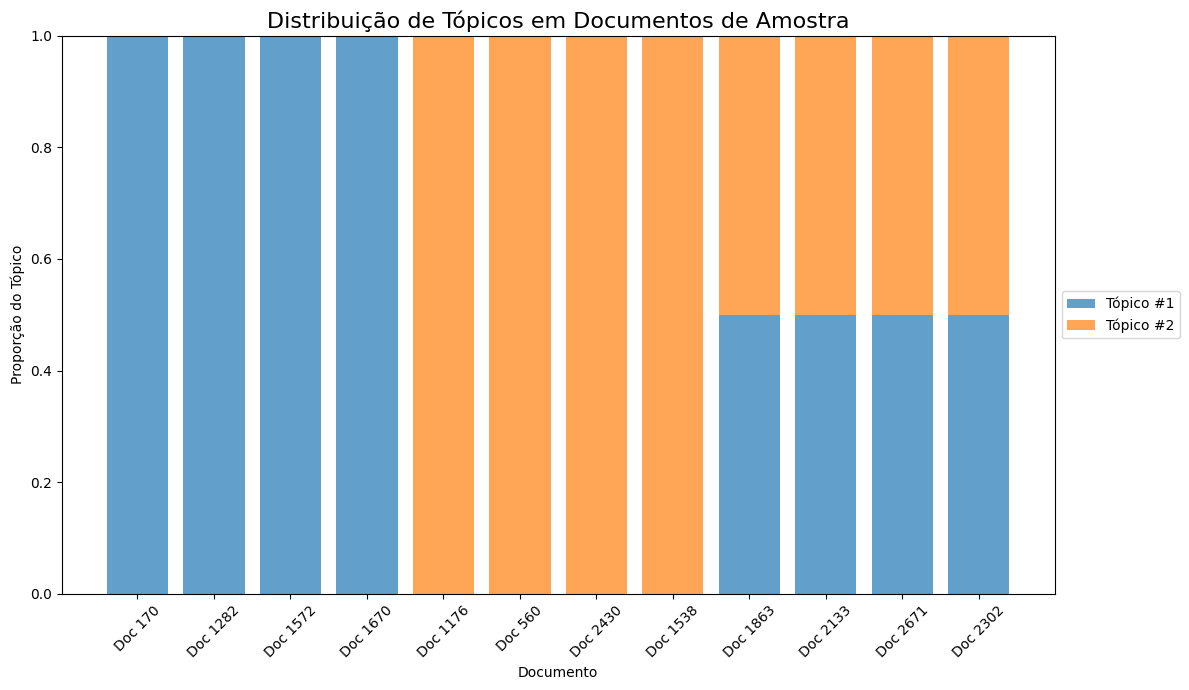

In [33]:
plot_significant_documents_per_topic(
    selected_docs=selected_docs,
    θ=θ_bow
)

In [34]:
print("=" * 40 + " Documentos Significativos por Tópico " + "=" * 40)

print_significant_documents_per_topic(
    selected_docs=selected_docs,
    θ=θ_bow,
    df=df,
    text_column=text_atribute,
    max_chars=600)

======================================== Documentos Significativos por Tópico ========================================
Documento #1 (idx=170)
Distribuição tópicos: ['100.00%', '0.00%']

Trecho dos primeiros 600 caracteres:
THE WHITE HOUSE

                  Office of the Press Secretary
                 (Vancouver, British Columbia) 
______________________________________________________________


                       BACKGROUND BRIEFING
                               BY
                 SENIOR ADMINISTRATION OFFICIALS


                          April 4, 1993
	     
                          Canada Place
                  Vancouver, British Columbia  


9:40 A.M. PST
	     
	     
	     Folks, we're about to start the BACKGROUND BRIEFING 
on the aid package.

	     SENIOR ADMINISTRATION OFFICIAL:  Good mornin
Documento #2 (idx=1282)
Distribuição tópicos: ['100.00%', '0.00%']

Trecho dos primeiros 600 caracteres:
THE WHITE HOUSE

                    Office of the Press Secretary
____

##### Executando RandomSearch para BoW + normalização

In [35]:
lda_result_bow_norm = run_lda_search(
    pipe=pipe_bow_norm,
    param_grid=param_grid_bow,
    scoring=lda_log_likelihood_scorer,
    df=df,
    title="LDA + BoW Normalizado",
    n_iter=N_ITER,
    top_n=3,
    cv=CV,
    n_jobs=-1
)

,mean_test_score,std_test_score,params
42,-21987.48891,190.55261,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.5, 'classifier__n_components': 2, 'classifier__doc_topic_prior': 0.1}"
3,-23036.14714,331.74422,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.5, 'classifier__n_components': 3, 'classifier__doc_topic_prior': 1.0}"
27,-24013.45382,327.14407,"{'preprocessor__text__vec__min_df': 15, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.5, 'classifier__n_components': 5, 'classifier__doc_topic_prior': 1.0}"


,mean_test_score,std_test_score,params
33,-49019.83174,1946.97487,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.2, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 8, 'classifier__doc_topic_prior': None}"
49,-44900.75390,1592.12634,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.9, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 5, 'classifier__doc_topic_prior': None}"
6,-42845.65570,337.78351,"{'preprocessor__text__vec__min_df': 5, 'preprocessor__text__vec__max_df': 0.9, 'classifier__topic_word_prior': 0.01, 'classifier__n_components': 3, 'classifier__doc_topic_prior': None}"


In [36]:
best_pipe_bow_norm = lda_result_bow_norm["best_pipe"]

model_bow_norm = best_pipe_bow_norm.named_steps["classifier"]

vectorizer_bow_norm = (
    best_pipe_bow_norm
    .named_steps["preprocessor"]
    .named_transformers_["text"]
    .named_steps["vec"]
)

vocab_bow_norm = vectorizer_bow_norm.get_feature_names_out()

X_bow_norm = (
    best_pipe_bow_norm
    .named_steps["preprocessor"]
    .transform(df)
)

θ_bow_norm = model_bow_norm.transform(X_bow_norm)

selected_docs_bow_norm = select_significant_documents_per_topic(
    θ=θ_bow_norm,
    X=X_bow_norm,
    n_docs=12
)

df["lda_θ_bow_norm_topic_0"] = θ_bow_norm[:, 0]
df["lda_θ_bow_norm_topic_1"] = θ_bow_norm[:, 1]

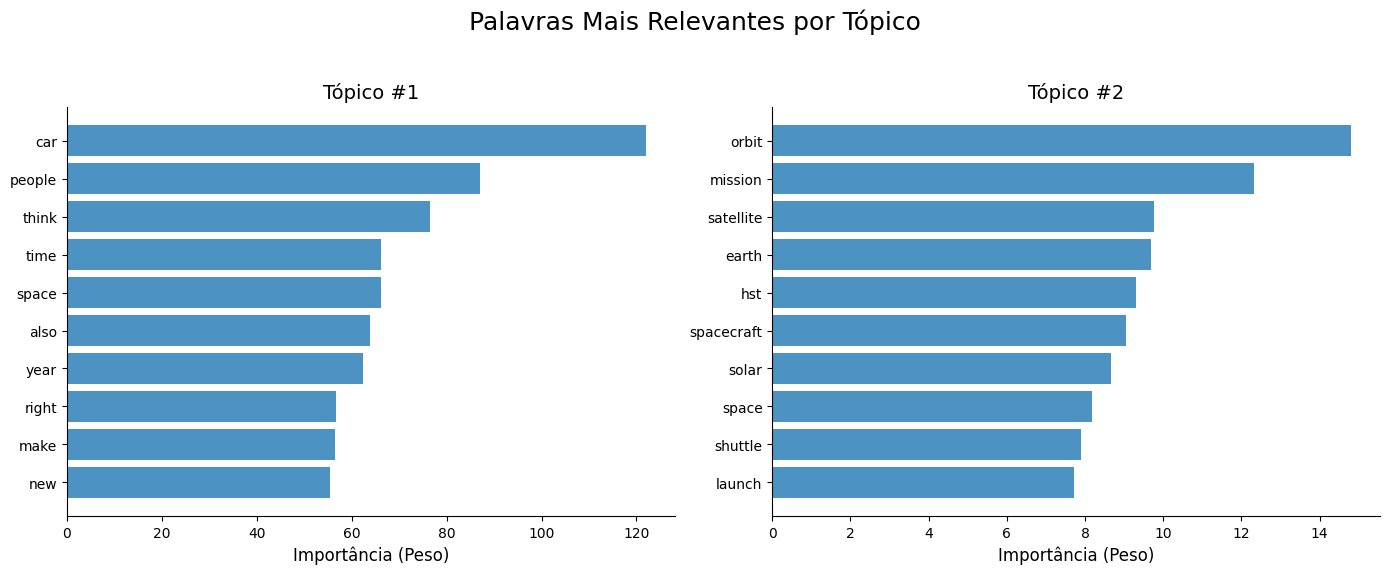

In [37]:
plot_words_per_topic(
    model=model_bow_norm,
    vocab=vocab_bow_norm,
    n_top_words=10
)

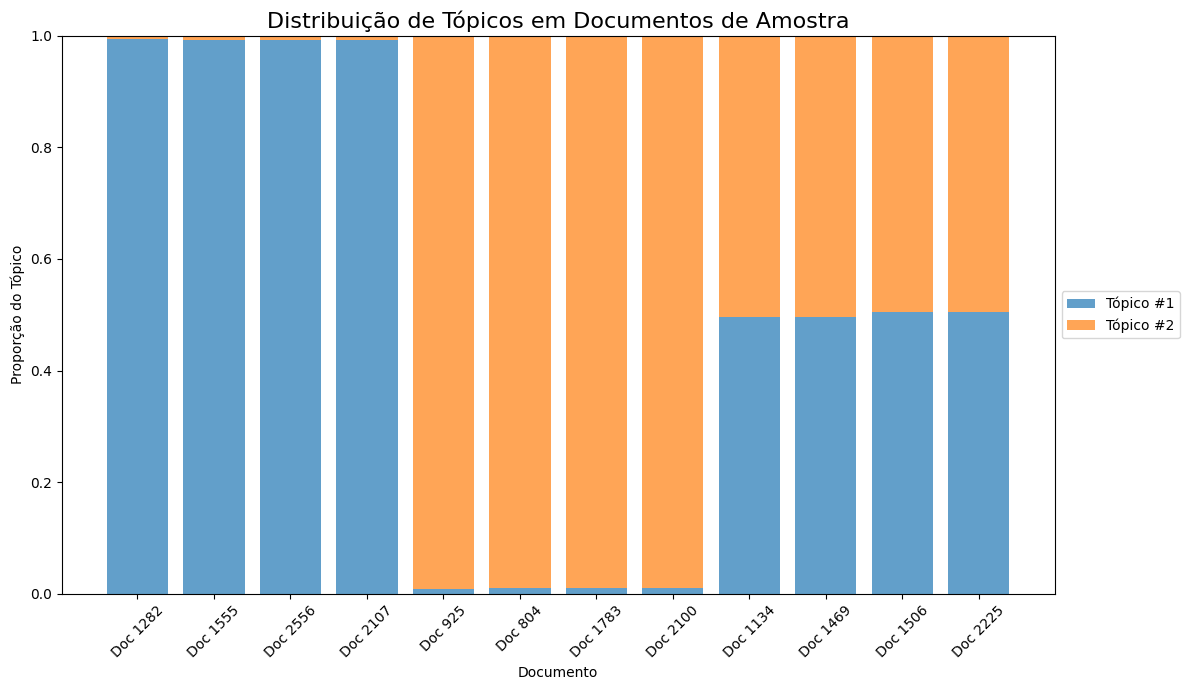

In [38]:

plot_significant_documents_per_topic(
    selected_docs=selected_docs_bow_norm,
    θ=θ_bow_norm
)


In [39]:
print("=" * 40 + " Documentos Significativos por Tópico " + "=" * 40)

print_significant_documents_per_topic(
    selected_docs=selected_docs_bow_norm,
    θ=θ_bow_norm,
    df=df,
    text_column="reviews",
    max_chars=600
)

======================================== Documentos Significativos por Tópico ========================================
Documento #1 (idx=1282)
Distribuição tópicos: ['99.36%', '0.64%']

Trecho dos primeiros 600 caracteres:
THE WHITE HOUSE

                    Office of the Press Secretary
______________________________________________________________
For Immediate Release                             April 23, 1993     

	     
                  PRESS CONFERENCE BY THE PRESIDENT
	     
	     
                            The East Room 


1:00 P.M. EDT
	     
	     
	     THE PRESIDENT:  Terry, do you have a question?
	     
	     Q	  Mr. President, there's a growing feeling that the 
Western response to bloodshed in Bosnia has been woefully inadequate.  
Holocaust survivor Elie Wiesel asked you yesterday to do som
Documento #2 (idx=1555)
Distribuição tópicos: ['99.33%', '0.67%']

Trecho dos primeiros 600 caracteres:
ETHER IMPLODES 2 EARTH CORE, IS GRAVITY!!!

  This paper BOTH describes 

### **3. Investigação (extra):**
<font size=3>

Quero comparar a estrutura geométrica dos clusters obtidos com KMeans sobre representações vetoriais reduzidas por SVD (LSA) com os tópicos probabilísticos identificados pelo modelo LDA.

Em particular, dado o que observamos e comentamos nas duas questões anteriores, quero propor as seguintes perguntas:

- Os clusters encontrados pelo KMeans no espaço latente do LSA correspondem aos tópicos identificados pelo LDA?
- A normalização vetorial beneficia métodos geométricos como KMeans, mas vai ajudar, prejudicar ou é neutro para modelos probabilísticos baseados em frequência, como o LDA?
- Tópicos semanticamente mais técnicos e especializados tendem a formar estruturas geométricas mais compactas e separáveis?
- É possível identificar alinhamento semântico entre estruturas geométricas obtidas via clustering e estruturas probabilísticas obtidas via modelagem de tópicos?

Para isso vamos:

- Comparar visualmente os clusters do KMeans com os tópicos do LDA, utilizando heatmaps de associação média de grupo por tópico;
- Analisar o impacto da normalização vetorial sobre:
  - os agrupamentos geométricos;
  - a coerência temática dos tópicos;
  - a relação entre distância euclidiana e similaridade por cosseno;

</font>

In [40]:
def plot_cluster_topic_heatmap(df, cluster_col, topic_cols, title):
    cluster_vs_topic = (
        df
        .groupby(cluster_col)[topic_cols]
        .mean()
    )

    plt.figure(figsize=(7, 4))

    sns.heatmap(
        cluster_vs_topic,
        annot=True,
        cmap="Blues",
        fmt=".3f"
    )

    plt.title(title)
    plt.xlabel("Tópicos LDA")
    plt.ylabel("Clusters KMeans")
    plt.tight_layout()
    plt.show()

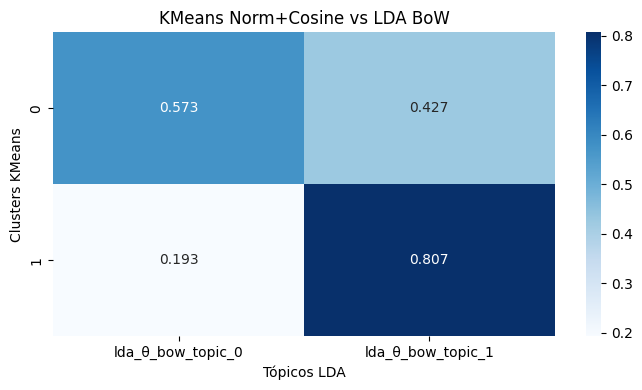

In [41]:
plot_cluster_topic_heatmap(
    df,
    "cluster_norm_cosine",
    ["lda_θ_bow_topic_0", "lda_θ_bow_topic_1"],
    "KMeans Norm+Cosine vs LDA BoW"
)


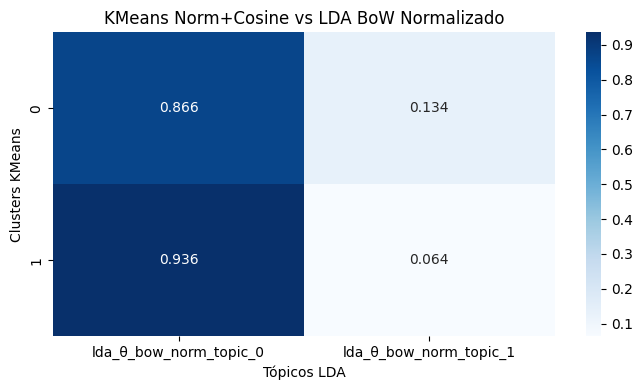

In [42]:

plot_cluster_topic_heatmap(
    df,
    "cluster_norm_cosine",
    ["lda_θ_bow_norm_topic_0", "lda_θ_bow_norm_topic_1"],
    "KMeans Norm+Cosine vs LDA BoW Normalizado"
)

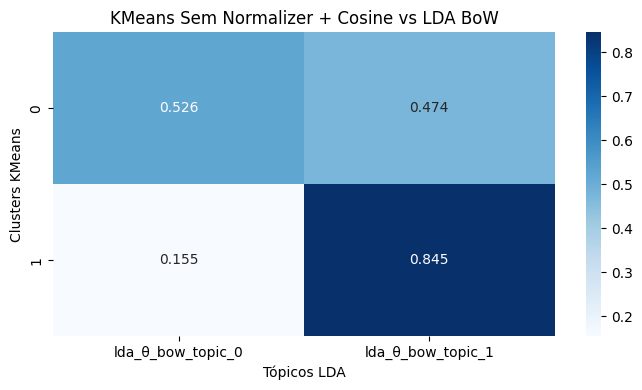

In [43]:
plot_cluster_topic_heatmap(
    df,
    "cluster_no_norm_cosine",
    ["lda_θ_bow_topic_0", "lda_θ_bow_topic_1"],
    "KMeans Sem Normalizer + Cosine vs LDA BoW"
)

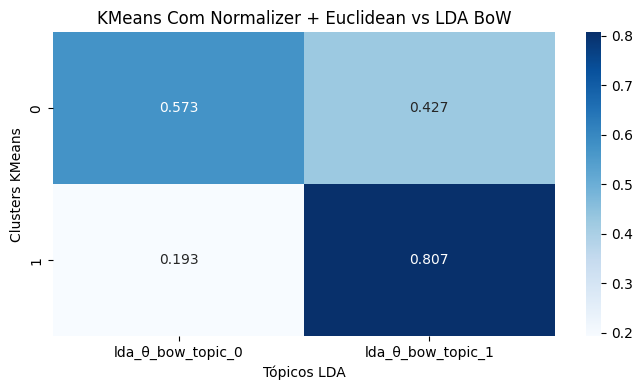

In [44]:
plot_cluster_topic_heatmap(
    df,
    "cluster_norm_euclid",
    ["lda_θ_bow_topic_0", "lda_θ_bow_topic_1"],
    "KMeans Com Normalizer + Euclidean vs LDA BoW"
)